# Loading & Plotting Rasters from PlateModelManager

Raster data represents information (like elevation, age, temperature, etc.) on a regular grid across Earth's surface. This notebook walks through plotting rasters. This notebook walks you through:

- Downloading rasters from EarthByte's webDAV server
- Plotting rasters!

### Setup

Let's begin by importing the required packages:

In [2]:
# Ensure you have the required packages installed:
# Run `pip install gplately cartopy matplotlib plate-model-manager` if you haven't already.
import cartopy.crs as ccrs
import gplately
import matplotlib.pyplot as plt
from plate_model_manager import PlateModelManager

### Downloading a Raster from webDAV server:

We begin by loading our plate model and creating `PlateReconstruction` and `PlotTopologies` objects for the [Muller et al. (2019)]("https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2018TC005462) plate tectonic model.

In [2]:
pm_manager = PlateModelManager()

# Load the Muller 2019 plate model 
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# This object will allow us to reconstruct the plate boundaries at different times
model = gplately.PlateReconstruction(
    muller2019_model.get_rotation_model(),
    muller2019_model.get_topologies(),
    muller2019_model.get_static_polygons()
)

# Coastlines, Continental polygons and COBs
coastlines = muller2019_model.get_layer('Coastlines')
continents = muller2019_model.get_layer('ContinentalPolygons')
COBs = muller2019_model.get_layer('COBs')

# Create PlotTopologies object
gplot = gplately.PlotTopologies(model, coastlines=coastlines, continents=continents, COBs=COBs)

Now we download a raster from EarthByte's webDAV server (for present day i.e. 0 Ma).

> `NOTE:` The 'Unrecognized zip data!' warning message was printed by the plate-model-manager. It is harmless and can be ignored!

In [3]:
# Set time
time = 0  # Ma

# Download and create a global raster for age grids at 0 Ma
muller_2019_age_grid = gplately.Raster(
    data=muller2019_model.get_raster("AgeGrids", time),
    plate_reconstruction=model,
    extent=[-180, 180, -90, 90],  # Defines the geographical boundaries of the raster grid (entire globe in this case)
)

You can now plot & reconstruct the raster!

### Plotting

The `muller_2019_age_grid` is a `Raster` object; this object allows us to work with age grids and other rasters. Let's visualise the data with `imshow`. 

The color map "YlGnBu" is used to show different values (like ocean crust age) using shades of yellow, green, and blue.

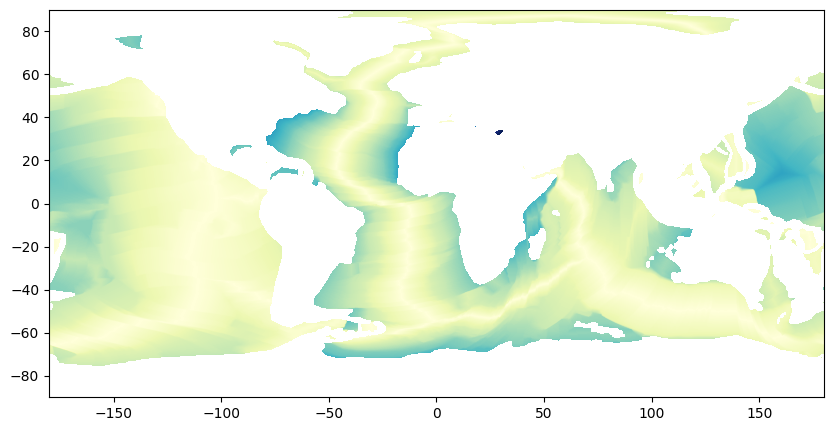

In [4]:
# Create a new figure for the plot, with a custom size
fig = plt.figure(figsize=(10, 6))

# Plot the raster data (age grid) using a color map
muller_2019_age_grid.imshow(cmap="YlGnBu")  # Try "twilight", "plasma" etc!

# Display the plot
plt.show()

Let’s plot this netCDF seafloor age grid together with coastlines, mid-ocean ridges, transform faults, and subduction zones (with teeth) derived from the Müller et al. (2019) plate model.

- The background colors (from the YlGnBu colormap) represent seafloor age in millions of years, where light yellow indicates younger oceanic crust near mid-ocean ridges and dark blue indicates older crust farther away.

- Black-edged gray shapes show the present-day landmasses.

- Blue lines mark mid-ocean ridges, where new crust is formed.

- Light blue lines indicate transform faults, connecting ridge segments.

- Magenta lines represent subduction zones, with magenta teeth showing the direction of subduction.

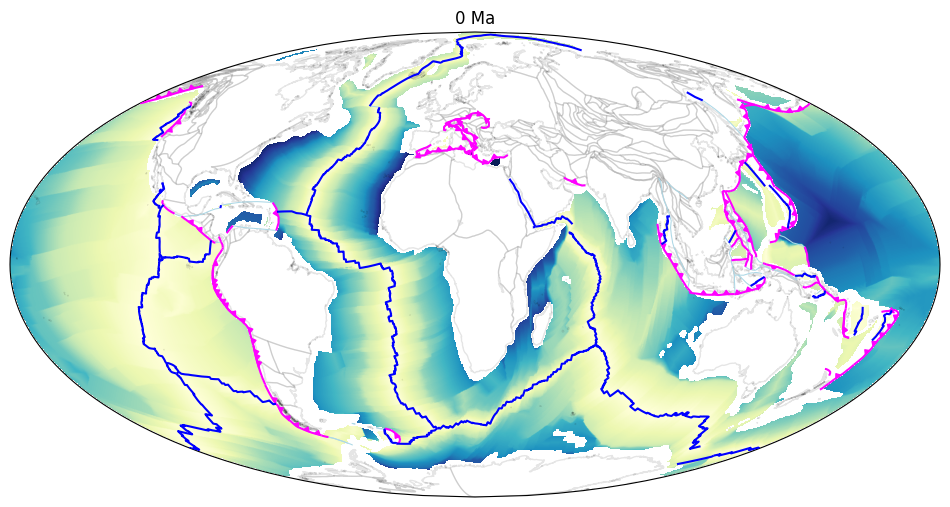

In [5]:
# Create a new figure and set up a Mollweide projection map
fig = plt.figure(figsize=(12, 8))
ax1 = fig.add_subplot(111, projection=ccrs.Mollweide(central_longitude=20))

# Set the reconstruction time for plotting
gplot.time = time

# Plot the seafloor age grid (e.g., colors represent ages in millions of years)
muller_2019_age_grid.imshow(ax1, cmap='YlGnBu', vmin=0, vmax=200)

# Overlay coastlines for landmasses (light gray with black edges)
gplot.plot_coastlines(ax1, edgecolor='k', facecolor='1', alpha=0.1)

# Plot plate boundaries:
gplot.plot_trenches(ax1, color='magenta', zorder=5)       # Subduction zones (trenches)
gplot.plot_ridges(ax1, color='b', zorder=5)               # Mid-ocean ridges
gplot.plot_transforms(ax1, color='lightblue', linewidth=0.75)  # Transform faults
gplot.plot_subduction_teeth(ax1, color='magenta')         # Subduction direction indicators ("teeth")

ax1.set_title("{} Ma".format(time))
plt.show()